In [3]:
import jax 
import jax.numpy as jnp
import numpy as np

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer
from probjax.nn import MLP

from models import EDM, Simformer

In [67]:
mlp = MLP([1,2,2,1], rngs=nnx.Rngs(jax.random.PRNGKey(0)))

mlp_def, mlp_params = nnx.split(mlp)

In [68]:
params_list, tree = jax.tree_util.tree_flatten(mlp_params)
dims_by_id = {i:int(np.prod(x.shape)) for i,x in enumerate(params_list)}

In [69]:
params_flat, unflatten = jax.flatten_util.ravel_pytree(mlp_params)

In [70]:
NUM_PARAMS = len(params_flat)
NUM_PARAMS

13

In [71]:
def generate_data(rng):
    x = jax.random.uniform(rng, (10,1), minval=-10, maxval=10)
    params = jax.random.normal(rng, (NUM_PARAMS,))
    params_unravel = unflatten(params)
    mlp = nnx.merge(mlp_def, params_unravel)
    y = mlp(x)
    y += jax.random.normal(rng, y.shape)*0.01
    data = jnp.concatenate([x, y], axis=-1)
    return params, data.reshape(-1)

In [72]:
from functools import partial


class PyTreeTokenizer(nnx.Module, experimental_pytree=True):
    def __init__(self, dims_by_id, encode_nets, decode_nets ,id_dim=50, cond_dim=10, context_net=None, rngs=None):
        self.dims_by_id = dims_by_id
        self.encode_nets = encode_nets
        self.decode_nets = decode_nets  
        self.embed_id = nnx.Embed(len(self.encode_nets), id_dim, rngs=rngs)
        self.context_net = context_net

    
    def __call__(self, x, node_ids, condition_mask=None, context=None, **kwargs):
        dims = np.asarray([self.dims_by_id[i] for i in node_ids])
        split_dims = np.cumsum(dims)[:-1]
        x_split = jnp.split(x, split_dims, axis=-1)
        net_subs = [self.encode_nets[i] for i in node_ids]
        val_embeddings = jax.tree_util.tree_map(lambda x, net: net(x)[...,None,:], x_split, net_subs)
        val_embedding = jnp.concatenate(val_embeddings, axis=-2)

        ids = self.embed_id(jnp.array(node_ids, dtype=jnp.int32))
        while len(ids.shape) < len(val_embedding.shape):
            ids = ids[None, ...]
            ids = jnp.repeat(ids, val_embedding.shape[0], axis=0)

        embeddings = jnp.concatenate([val_embedding, ids], axis=-1)
        if context is not None:
            context = self.context_net(context)[...,None,:]
            embeddings = embeddings + context
        
        return embeddings
    
    
    def decode(self, h, node_ids, condition_mask=None, context=None, **kwargs):
        hs = jnp.split(h, h.shape[-2], axis=-2)
        net_subs = [self.decode_nets[i] for i in node_ids]
        x = jax.tree_util.tree_map(lambda x, net: net(x), hs, net_subs)
        out =  jnp.concatenate(x, axis=-1)
        out = jnp.squeeze(out, axis=-2)
        return out

In [73]:
encode_nets = [nnx.Linear(dims_by_id[i], 50, rngs=nnx.Rngs(jax.random.PRNGKey(i))) for i in range(len(dims_by_id))]
decode_nets = [nnx.Linear(100, dims_by_id[i], rngs=nnx.Rngs(jax.random.PRNGKey(i))) for i in range(len(dims_by_id))]

context_net = MLP([20, 100,50], rngs=nnx.Rngs(jax.random.PRNGKey(25)))
tokenizer = PyTreeTokenizer(dims_by_id, encode_nets, decode_nets, rngs=nnx.Rngs(jax.random.PRNGKey(0)))

In [74]:
thetas, datas = jax.vmap(generate_data)(jax.random.split(jax.random.key(0), 100))

In [75]:
net = Simformer(tokenizer, model_dim=100, rngs=nnx.Rngs(42), context_embed=context_net, widening_factor=4)
model = EDM(net)

graphdef, params, state = nnx.split(model, nnx.Param, nnx.Variable)

In [76]:
node_ids = tuple([0,1,2,3,4,5])

model(jnp.ones((100,1))*0.5, thetas, node_ids, context=datas, condition_mask=None) - thetas

(100, 1, 50) (100, 1, 50)


Array([[ 0.302,  0.167, -0.057, ...,  0.009,  1.045, -0.121],
       [-0.546,  0.355, -0.226, ..., -0.512,  0.498, -0.51 ],
       [ 0.121, -0.069,  0.652, ...,  0.137,  0.673,  0.16 ],
       ...,
       [-0.314, -0.166, -0.282, ...,  0.562,  1.496,  0.606],
       [-0.359, -0.721, -0.836, ..., -0.039,  0.289, -0.309],
       [-0.425, -0.375,  0.016, ..., -0.014,  0.31 ,  0.065]],      dtype=float32)

In [77]:
# from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

# def mean_fn(t, x):
#     return x

# def std_fn(t, x):
#     return model.std_fn(t) 

# denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn, axis=-1)

In [78]:
def loss_fn(params, key):
    model = nnx.merge(graphdef, params, state)
    rng, rng_loss, rng_time = jax.random.split(key,3)
    thetas, datas = jax.vmap(generate_data)(jax.random.split(rng, 1000))

    logt = jax.random.normal(rng_time, shape=(1000, 1)) * 1.2 - 1.2
    t = jnp.exp(logt) + 0.001

    theta_noisy = thetas + jax.random.normal(rng_loss, thetas.shape) * t
    denoised_thetas = model(t, theta_noisy, tuple(node_ids), context=datas, condition_mask=None)
    weights = model.weight_fn(t)
    
    loss = weights[...,None]*(thetas - denoised_thetas)**2
    return loss.mean()

In [91]:
loss_fn(params, jax.random.PRNGKey(5))

(1000, 1, 50) (1000, 1, 50)


Array(0.95, dtype=float32)

In [80]:
import optax

optimizer = optax.chain(optax.adaptive_grad_clip(10.0), optax.adamw(1e-4))

params = nnx.state(model)
opt_state = optimizer.init(params)
key = jax.random.PRNGKey(0)

@jax.jit
def update(params, opt_state, key):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [81]:

for i in range(10_000):
    key, subkey = jax.random.split(key)
    params, opt_state, loss = update(params, opt_state, subkey)
    if i % 1000 == 0:
        print(loss)

(1000, 1, 50) (1000, 1, 50)
1.87053
(1000, 1, 50) (1000, 1, 50)
0.9863712
0.98974955
0.9817626


KeyboardInterrupt: 

In [82]:
model = nnx.merge(graphdef, params, state)

In [83]:
from probjax.utils.odeint import odeint

def naive_diffusion_sampling(key, x_o):
    
    T_end = 10.
    rng_init, _ = jax.random.split(key)
    eps = jax.random.normal(rng_init, (NUM_PARAMS,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.01, T_end, 500)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((1,NUM_PARAMS))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_, node_ids=node_ids, condition_mask=None, context=x_o[None])
        backward_f = (f -0.5*g**2*score).reshape(x.shape)
        return backward_f

    return odeint(drift, eps,ts[::-1], method="heun")[-1]

In [84]:
theta, x_o = generate_data(jax.random.PRNGKey(0))

In [85]:
samples = jax.vmap(lambda k: naive_diffusion_sampling(k, datas[0]))(jax.random.split(jax.random.PRNGKey(0), 1000))

(1, 1, 50) (1, 1, 50)
(1, 1, 50) (1, 1, 50)
(1, 1, 50) (1, 1, 50)


(array([ 2.,  1.,  0.,  1.,  0.,  1.,  3.,  3.,  2.,  3.,  2.,  1.,  5.,
         3.,  3.,  6.,  5.,  4.,  0.,  5.,  5.,  9.,  7., 17., 17.,  8.,
         8., 18., 18.,  6., 16., 27., 18., 11., 13., 20., 24., 21., 25.,
        19., 20., 21., 21., 20., 17., 24., 25., 23., 12., 16., 23., 20.,
        22., 17., 14., 18., 35., 14., 13., 16., 16., 18., 13., 25., 13.,
        10.,  9.,  9., 20., 10.,  9.,  9., 14.,  8.,  7.,  5.,  5.,  7.,
        10.,  2.,  3.,  3.,  3.,  3.,  4.,  3.,  0.,  1.,  0.,  0.,  4.,
         3.,  0.,  2.,  0.,  1.,  2.,  0.,  0.,  1.]),
 array([-2.784, -2.727, -2.669, -2.611, -2.554, -2.496, -2.438, -2.381,
        -2.323, -2.265, -2.208, -2.15 , -2.092, -2.035, -1.977, -1.919,
        -1.861, -1.804, -1.746, -1.688, -1.631, -1.573, -1.515, -1.458,
        -1.4  , -1.342, -1.285, -1.227, -1.169, -1.112, -1.054, -0.996,
        -0.939, -0.881, -0.823, -0.766, -0.708, -0.65 , -0.592, -0.535,
        -0.477, -0.419, -0.362, -0.304, -0.246, -0.189, -0.131, -0.073,
  

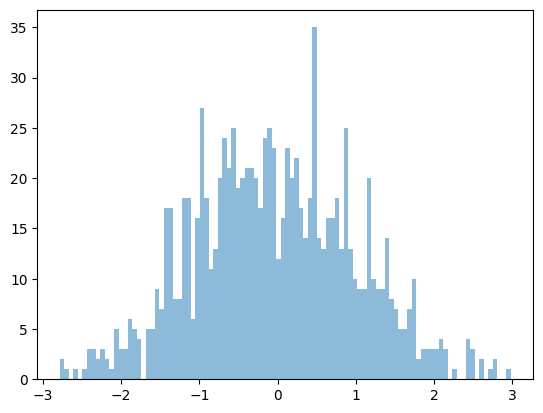

In [87]:
plt.hist(samples[:,0], bins=100, alpha=0.5)

In [88]:
def pred(params, x):
    unflat_params = unflatten(params)
    nnx.update(mlp, unflat_params)
    return mlp(x)

In [89]:
y = pred(samples[0], x_o[::2, None])

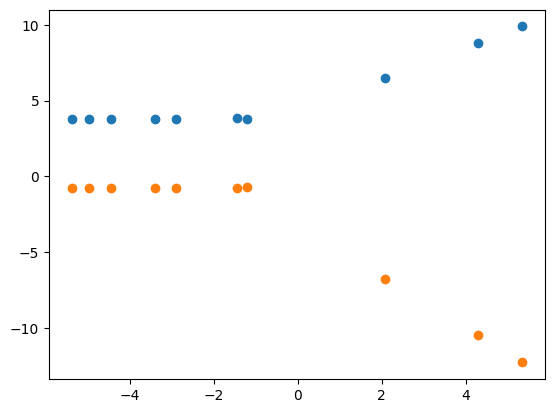

In [90]:
plt.plot(x_o[::2], x_o[1::2], 'o')
plt.plot(x_o[::2], y, 'o')